# Unit14_Example_04 | 化工案例四：反應速率常數與溫度之相關分析與線性回歸 (Arrhenius Regression)

本 Notebook 以 **Arrhenius 方程式驗證** 為化工案例，示範如何使用 `scipy.stats` 執行完整的統計推論流程。

## 目標
- 合成含量測誤差的 Arrhenius 線性化數據 $(1/T,\ \ln k)$
- 計算 Pearson/Spearman 相關係數並解讀 p 值
- 使用 `scipy.stats.linregress()` 進行一元線性回歸
- 由斜率計算活化能 $E_a$ 與 $95\%$ 信賴區間
- 對回歸係數（斜率、截距）各自執行 t 檢定
- 與 Unit13 的 `scipy.linalg.lstsq()` 進行比較
- 繪製 $1/T$ vs $\ln k$ 散佈圖、回歸線與 $95\%$ 預測區間

---
### 0. 環境設定

In [12]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit14_Example_04'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit14'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit14
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_04
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_04\figs


---
### 1. 載入套件

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, linalg
import warnings
warnings.filterwarnings('ignore')

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
})

import scipy
import matplotlib
print("套件載入完成:")
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")

套件載入完成:
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題描述與模擬數據

**Arrhenius 方程式：**

$$k = A \cdot e^{-E_a / RT}$$

線性化後：

$$\ln k = \ln A - \frac{E_a}{R} \cdot \frac{1}{T}$$

令 $y = \ln k$ ， $x = 1/T$ ，模型為斜率 $b = -E_a/R$ 、截距 $a = \ln A$ 的線性方程式。

**真實參數設定：**

| 參數 | 符號 | 真實值 |
|------|------|--------|
| 指前因子 | $A$ | $1.0 \times 10^{13}\ \text{s}^{-1}$ |
| 活化能 | $E_a$ | $80\ \text{kJ/mol}$ |
| 溫度範圍 | $T$ | $300 \sim 600\ \text{K}$ ，共 12 點 |
| 量測誤差 | $\sigma_{\ln k}$ | $0.15$ |

In [13]:
# ===== Arrhenius 真實參數 =====
A_true  = 1.0e13          # 指前因子 (s^-1)
Ea_true = 80e3             # 活化能 (J/mol)
R       = 8.314            # 通用氣體常數 (J/mol/K)

# ===== 模擬溫度（12 個量測點）並生成含誤差的 ln k =====
rng     = np.random.default_rng(42)
T_vals  = np.linspace(300, 600, 12)         # 溫度 (K)
inv_T   = 1.0 / T_vals                      # 1/T (K^-1)

# 真實 ln k 值
lnk_true = np.log(A_true) - (Ea_true / R) * inv_T

# 加入高斯量測雜訊
sigma_noise = 0.15
lnk_obs     = lnk_true + rng.normal(0, sigma_noise, size=len(T_vals))

n = len(T_vals)

print(f"樣本數 n = {n}")
print(f"真實活化能 Ea = {Ea_true/1000:.1f} kJ/mol")
print(f"真實斜率 b = -Ea/R = {-Ea_true/R:.2f} K")
print(f"真實截距 a = ln(A) = {np.log(A_true):.4f}")
print()
print(f"{'序號':>4} {'T (K)':>8} {'1/T (K⁻¹)':>14} {'ln k (真實)':>14} {'ln k (觀測)':>14}")
print("-" * 60)
for i in range(n):
    print(f"{i+1:>4} {T_vals[i]:>8.1f} {inv_T[i]:>14.6f} "
          f"{lnk_true[i]:>14.4f} {lnk_obs[i]:>14.4f}")

樣本數 n = 12
真實活化能 Ea = 80.0 kJ/mol
真實斜率 b = -Ea/R = -9622.32 K
真實截距 a = ln(A) = 29.9336

  序號    T (K)      1/T (K⁻¹)      ln k (真實)      ln k (觀測)
------------------------------------------------------------
   1    300.0       0.003333        -2.1408        -2.0951
   2    327.3       0.003056         0.5321         0.3761
   3    354.5       0.002821         2.7937         2.9063
   4    381.8       0.002619         4.7323         4.8734
   5    409.1       0.002444         6.4124         6.1197
   6    436.4       0.002292         7.8824         7.6871
   7    463.6       0.002157         9.1796         9.1988
   8    490.9       0.002037        10.3326        10.2851
   9    518.2       0.001930        11.3642        11.3617
  10    545.5       0.001833        12.2927        12.1647
  11    572.7       0.001746        13.1327        13.2646
  12    600.0       0.001667        13.8964        14.0131


---
### 3. Pearson 相關分析

**Pearson 相關係數：**

$$r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2 \cdot \sum(y_i - \bar{y})^2}}$$

相關性 t 檢定統計量：

$$t = \frac{r\sqrt{n-2}}{\sqrt{1-r^2}} \sim t(n-2), \quad H_0: \rho = 0$$

In [14]:
# Pearson 相關係數
r_pearson, p_pearson = stats.pearsonr(inv_T, lnk_obs)

print("Pearson 相關分析結果:")
print(f"  相關係數 r    = {r_pearson:.6f}")
print(f"  p 值          = {p_pearson:.2e}")
print(f"  r²            = {r_pearson**2:.6f}  (決定係數，解釋 {r_pearson**2*100:.2f}% 的變異)")
print()

# 手動計算 t 統計量驗證
t_manual = r_pearson * np.sqrt(n - 2) / np.sqrt(1 - r_pearson**2)
p_manual = 2 * stats.t.sf(abs(t_manual), df=n-2)
print(f"  手動驗證 t 統計量 = {t_manual:.4f}")
print(f"  手動驗證 p 值     = {p_manual:.2e}")
print()

if p_pearson < 0.05:
    print("  → 結論: 拒絕 H₀ (p < 0.05)")
    print(f"  → 1/T 與 ln k 之間存在顯著的負線性相關 (r = {r_pearson:.4f})")
    print("  → 斜率為負，符合 Arrhenius 方程式的預期")

Pearson 相關分析結果:
  相關係數 r    = -0.999619
  p 值          = 6.35e-17
  r²            = 0.999237  (決定係數，解釋 99.92% 的變異)

  手動驗證 t 統計量 = -114.4666
  手動驗證 p 值     = 6.35e-17

  → 結論: 拒絕 H₀ (p < 0.05)
  → 1/T 與 ln k 之間存在顯著的負線性相關 (r = -0.9996)
  → 斜率為負，符合 Arrhenius 方程式的預期


---
### 4. Spearman 等級相關分析

**Spearman 相關係數**為無母數方法，適用於非常態分布或含離群值的場合：

$$r_s = 1 - \frac{6\sum d_i^2}{n(n^2-1)}$$

- 捕捉**單調相關**（不限線性）
- 對離群值具穩健性
- 若數據近似線性， $r_s \approx r_{Pearson}$

In [15]:
# Spearman 等級相關係數
r_spearman, p_spearman = stats.spearmanr(inv_T, lnk_obs)

print("Spearman 等級相關分析結果:")
print(f"  Spearman ρ    = {r_spearman:.6f}")
print(f"  p 值          = {p_spearman:.2e}")
print()
print("Pearson vs Spearman 比較:")
print(f"  {'方法':<20} {'相關係數':>12} {'p 值':>14} {'特性':>30}")
print("-" * 80)
print(f"  {'Pearson r':<20} {r_pearson:>12.6f} {p_pearson:>14.2e} {'線性相關，假設常態':>30}")
print(f"  {'Spearman ρ':<20} {r_spearman:>12.6f} {p_spearman:>14.2e} {'單調相關，無母數':>30}")
print()
diff = abs(r_pearson - r_spearman)
print(f"  兩者差異 |r - ρ| = {diff:.6f}")
if diff < 0.01:
    print("  → 差異極小，ln k 與 1/T 之間為純線性關係（符合 Arrhenius 假設）")

Spearman 等級相關分析結果:
  Spearman ρ    = -1.000000
  p 值          = 0.00e+00

Pearson vs Spearman 比較:
  方法                           相關係數            p 值                             特性
--------------------------------------------------------------------------------
  Pearson r               -0.999619       6.35e-17                      線性相關，假設常態
  Spearman ρ              -1.000000       0.00e+00                       單調相關，無母數

  兩者差異 |r - ρ| = 0.000381
  → 差異極小，ln k 與 1/T 之間為純線性關係（符合 Arrhenius 假設）


---
### 5. 一元線性回歸：scipy.stats.linregress()

`scipy.stats.linregress(x, y)` 回傳具名元組：

| 欄位 | 說明 |
|------|------|
| `slope` | 迴歸斜率 $\hat{b} = -E_a/R$ |
| `intercept` | 迴歸截距 $\hat{a} = \ln A$ |
| `rvalue` | Pearson 相關係數 $r$ |
| `pvalue` | 斜率 t 檢定雙尾 p 值（ $H_0: b=0$ ） |
| `stderr` | 斜率標準誤 $SE_b$ |
| `intercept_stderr` | 截距標準誤 $SE_a$ |

In [16]:
# 執行一元線性回歸
result    = stats.linregress(inv_T, lnk_obs)

slope     = result.slope               # 斜率 = -Ea/R
intercept = result.intercept           # 截距 = ln(A)
r_value   = result.rvalue              # Pearson r
p_value   = result.pvalue              # 斜率 t 檢定 p 值
se_slope  = result.stderr              # 斜率標準誤 SE_b
se_inter  = result.intercept_stderr    # 截距標準誤 SE_a
R_sq      = r_value**2                 # 決定係數

print("scipy.stats.linregress() 回歸結果:")
print(f"  斜率      slope     = {slope:.4f}  (對應 -Ea/R)")
print(f"  截距      intercept = {intercept:.4f}  (對應 ln A)")
print(f"  r 值      rvalue    = {r_value:.6f}")
print(f"  R²                  = {R_sq:.6f}")
print(f"  p 值      pvalue    = {p_value:.2e}  (斜率 t 檢定)")
print(f"  斜率標準誤 stderr   = {se_slope:.4f}")
print(f"  截距標準誤          = {se_inter:.4f}")
print()

# 比較回歸斜率與真實斜率
b_true = -Ea_true / R
a_true = np.log(A_true)
print("回歸結果 vs 真實參數:")
print(f"  {'參數':<15} {'真實值':>14} {'估計值':>14} {'誤差%':>10}")
print("-" * 56)
print(f"  {'斜率 -Ea/R':<15} {b_true:>14.4f} {slope:>14.4f} {(slope-b_true)/abs(b_true)*100:>9.3f}%")
print(f"  {'截距 ln A':<15} {a_true:>14.4f} {intercept:>14.4f} {(intercept-a_true)/abs(a_true)*100:>9.3f}%")

scipy.stats.linregress() 回歸結果:
  斜率      slope     = -9646.6240  (對應 -Ea/R)
  截距      intercept = 29.9689  (對應 ln A)
  r 值      rvalue    = -0.999619
  R²                  = 0.999237
  p 值      pvalue    = 6.35e-17  (斜率 t 檢定)
  斜率標準誤 stderr   = 84.2746
  截距標準誤          = 0.2009

回歸結果 vs 真實參數:
  參數                         真實值            估計值        誤差%
--------------------------------------------------------
  斜率 -Ea/R            -9622.3238     -9646.6240    -0.253%
  截距 ln A                29.9336        29.9689     0.118%


---
### 6. 活化能估計與信賴區間

由斜率 $\hat{b} = -E_a/R$ 計算活化能： $\hat{E}_a = -\hat{b} \cdot R$

標準誤傳播： $SE_{E_a} = SE_b \cdot R$

$95\%$ 信賴區間（ $t$ 分布， $df = n - 2$ ）：

$$\hat{E}_a \pm t_{\alpha/2,\ n-2} \cdot SE_{E_a}$$

In [17]:
# 由斜率計算活化能
Ea_est  = -slope * R          # 估計活化能 (J/mol)
SE_Ea   = se_slope * R        # Ea 的標準誤

# 95% 信賴區間 (t 分布, df = n - 2)
alpha   = 0.05
df_reg  = n - 2
t_crit  = stats.t.ppf(1 - alpha/2, df=df_reg)

CI_Ea_lo = Ea_est - t_crit * SE_Ea
CI_Ea_hi = Ea_est + t_crit * SE_Ea

# 指前因子 A = exp(intercept)
A_est = np.exp(intercept)

print("活化能估計結果:")
print(f"  估計活化能 Ea  = {Ea_est:.2f} J/mol  = {Ea_est/1000:.4f} kJ/mol")
print(f"  標準誤 SE_Ea   = {SE_Ea:.2f} J/mol")
print(f"  自由度 df      = n - 2 = {df_reg}")
print(f"  臨界 t 值      = t(0.025, {df_reg}) = {t_crit:.4f}")
print()
print(f"  95% 信賴區間:")
print(f"    下界 = {CI_Ea_lo:.2f} J/mol  = {CI_Ea_lo/1000:.4f} kJ/mol")
print(f"    上界 = {CI_Ea_hi:.2f} J/mol  = {CI_Ea_hi/1000:.4f} kJ/mol")
print()
print(f"  指前因子估計 A = exp({intercept:.4f}) = {A_est:.4e} s⁻¹")
print()
print("與真實值比較:")
print(f"  真實 Ea = {Ea_true:.2f} J/mol = {Ea_true/1000:.1f} kJ/mol")
ci_contains = CI_Ea_lo <= Ea_true <= CI_Ea_hi
print(f"  真實值是否在 95% CI 內: {'是 ✓' if ci_contains else '否 ✗'}")
print(f"  CI 寬度: ±{t_crit * SE_Ea/1000:.4f} kJ/mol （約 {t_crit*SE_Ea/Ea_est*100:.2f}%）")

活化能估計結果:
  估計活化能 Ea  = 80202.03 J/mol  = 80.2020 kJ/mol
  標準誤 SE_Ea   = 700.66 J/mol
  自由度 df      = n - 2 = 10
  臨界 t 值      = t(0.025, 10) = 2.2281

  95% 信賴區間:
    下界 = 78640.87 J/mol  = 78.6409 kJ/mol
    上界 = 81763.20 J/mol  = 81.7632 kJ/mol

  指前因子估計 A = exp(29.9689) = 1.0360e+13 s⁻¹

與真實值比較:
  真實 Ea = 80000.00 J/mol = 80.0 kJ/mol
  真實值是否在 95% CI 內: 是 ✓
  CI 寬度: ±1.5612 kJ/mol （約 1.95%）


---
### 7. 回歸係數 t 檢定

對斜率與截距分別執行雙尾 t 檢定：

$$t_b = \frac{\hat{b}}{SE_b}, \quad t_a = \frac{\hat{a}}{SE_a} \quad \sim t(n-2)$$

- **斜率**： $H_0: b = 0$ （溫度倒數對 $\ln k$ 無線性影響）
- **截距**： $H_0: a = 0$ （ $\ln A = 0$ ，即 $A = 1$ ）

In [18]:
# 回歸係數 t 檢定
t_slope = slope / se_slope
p_slope = 2 * stats.t.sf(abs(t_slope), df=df_reg)

t_inter = intercept / se_inter
p_inter = 2 * stats.t.sf(abs(t_inter), df=df_reg)

print(f"回歸係數 t 檢定結果 (df = n - 2 = {df_reg}):")
print()
print(f"  {'係數':<12} {'估計值':>14} {'標準誤':>12} {'t 值':>12} {'p 值':>14} {'顯著性':>8}")
print("-" * 76)
for name, est, se, tv, pv in [
    ("斜率 (b)",  slope,     se_slope, t_slope, p_slope),
    ("截距 (a)",  intercept, se_inter, t_inter, p_inter)
]:
    sig    = "***" if pv < 0.001 else ("**" if pv < 0.01 else ("*" if pv < 0.05 else "ns"))
    pv_str = f"{pv:.2e}" if pv < 1e-4 else f"{pv:.6f}"
    print(f"  {name:<12} {est:>14.4f} {se:>12.4f} {tv:>12.4f} {pv_str:>14} {sig:>8}")
print()
print("  顯著性標記: *** p<0.001  ** p<0.01  * p<0.05  ns p≥0.05")
print()
print(f"  驗證: scipy linregress pvalue = {p_value:.2e} = 手動斜率 p 值 {p_slope:.2e} "
      f"→ {'一致 ✓' if abs(p_value - p_slope) < 1e-20 else '不一致 ✗'}")
print()
print("物理意義:")
print(f"  斜率 t 檢定：t = {t_slope:.2f}, p ≪ 0.001")
print("  → 拒絕 H₀：1/T 對 ln k 存在顯著線性影響，Arrhenius 關係在統計上成立")
print(f"  截距 t 檢定：t = {t_inter:.2f}, p ≪ 0.001")
print("  → 拒絕 H₀：ln A 顯著異於零，指前因子 A 顯著不等於 1")

回歸係數 t 檢定結果 (df = n - 2 = 10):

  係數                      估計值          標準誤          t 值            p 值      顯著性
----------------------------------------------------------------------------
  斜率 (b)           -9646.6240      84.2746    -114.4666       6.35e-17      ***
  截距 (a)              29.9689       0.2009     149.1644       4.50e-18      ***

  顯著性標記: *** p<0.001  ** p<0.01  * p<0.05  ns p≥0.05

  驗證: scipy linregress pvalue = 6.35e-17 = 手動斜率 p 值 6.35e-17 → 一致 ✓

物理意義:
  斜率 t 檢定：t = -114.47, p ≪ 0.001
  → 拒絕 H₀：1/T 對 ln k 存在顯著線性影響，Arrhenius 關係在統計上成立
  截距 t 檢定：t = 149.16, p ≪ 0.001
  → 拒絕 H₀：ln A 顯著異於零，指前因子 A 顯著不等於 1


---
### 8. 與 Unit13 lstsq 方法的比較

| 方法 | 模組 | 主要用途 | 統計推論 |
|------|------|----------|---------|
| `scipy.stats.linregress()` | `scipy.stats` | 統計推論：t 檢定、p 值、CI | ✓ 直接提供 |
| `scipy.linalg.lstsq()` | `scipy.linalg` | 矩陣求解：最小平方解 | ✗ 需手動計算 |

兩方法的點估計（斜率、截距）完全一致，均採最小平方準則。

In [19]:
# 建立設計矩陣 [1, x]
X_mat = np.column_stack([np.ones(n), inv_T])   # (12, 2)

# lstsq 求解
coeffs, _, _, _ = linalg.lstsq(X_mat, lnk_obs)
a_lstsq = coeffs[0]   # 截距
b_lstsq = coeffs[1]   # 斜率

# 手動計算 R²
lnk_pred_ls = X_mat @ coeffs
SS_res_ls   = np.sum((lnk_obs - lnk_pred_ls)**2)
SS_tot_ls   = np.sum((lnk_obs - np.mean(lnk_obs))**2)
R2_lstsq    = 1 - SS_res_ls / SS_tot_ls

print("scipy.linalg.lstsq() 回歸結果:")
print(f"  截距 a = {a_lstsq:.6f}")
print(f"  斜率 b = {b_lstsq:.6f}")
print(f"  R²     = {R2_lstsq:.6f}")
print()
print("兩方法結果比較:")
print(f"  {'方法':<30} {'截距':>14} {'斜率':>14} {'R²':>12}")
print("-" * 74)
print(f"  {'scipy.stats.linregress()':<30} {intercept:>14.6f} {slope:>14.6f} {R_sq:>12.6f}")
print(f"  {'scipy.linalg.lstsq()':<30} {a_lstsq:>14.6f} {b_lstsq:>14.6f} {R2_lstsq:>12.6f}")
print()
d_intercept = abs(intercept - a_lstsq)
d_slope     = abs(slope - b_lstsq)
print(f"  截距差異: {d_intercept:.2e}  →  {'一致 ✓' if d_intercept < 1e-6 else '不一致 ✗'}")
print(f"  斜率差異: {d_slope:.2e}  →  {'一致 ✓' if d_slope < 1e-6 else '不一致 ✗'}")
print()
print("說明: 兩方法均採用最小平方準則，斜率與截距估計值完全一致。")
print("  linregress 適合統計推論（直接提供 t 檢定、p 值）；")
print("  lstsq 適合多元回歸或需要自訂設計矩陣的場合。")

scipy.linalg.lstsq() 回歸結果:
  截距 a = 29.968942
  斜率 b = -9646.624023
  R²     = 0.999237

兩方法結果比較:
  方法                                         截距             斜率           R²
--------------------------------------------------------------------------
  scipy.stats.linregress()            29.968942   -9646.624023     0.999237
  scipy.linalg.lstsq()                29.968942   -9646.624023     0.999237

  截距差異: 1.42e-14  →  一致 ✓
  斜率差異: 7.28e-12  →  一致 ✓

說明: 兩方法均採用最小平方準則，斜率與截距估計值完全一致。
  linregress 適合統計推論（直接提供 t 檢定、p 值）；
  lstsq 適合多元回歸或需要自訂設計矩陣的場合。


---
### 9. 視覺化分析

**$95\%$ 預測區間**（對單一新觀測值的預測範圍）：

$$\hat{y} \pm t_{\alpha/2,\ n-2} \cdot s \cdot \sqrt{1 + \frac{1}{n} + \frac{(x - \bar{x})^2}{\sum(x_i - \bar{x})^2}}$$

其中 $s = \sqrt{SS_{res}/(n-2)}$ 為殘差標準差。預測區間在兩端（遠離 $\bar{x}$ ）略寬，為最小平方回歸的正常特性。

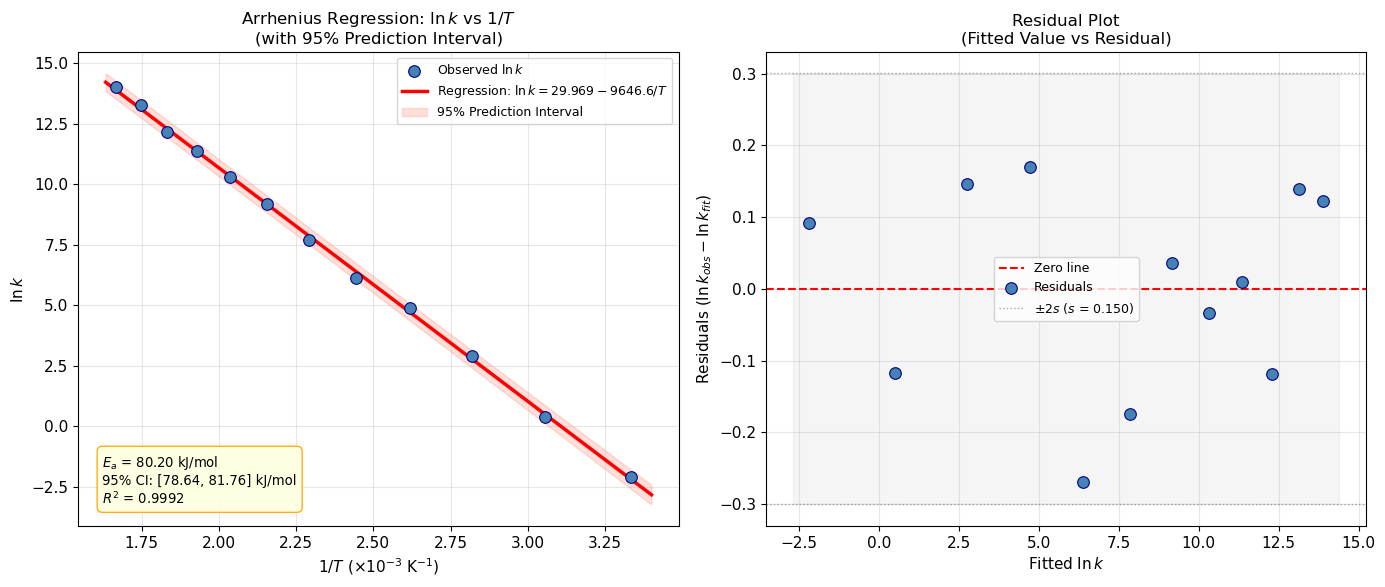

圖檔已儲存: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_04\figs\arrhenius_regression.png

左圖: 散佈點緊密分布於回歸直線附近，預測區間（粉色帶狀）在端點略寬。
右圖: 殘差無系統性趨勢，均在 ±2s 範圍內，確認線性假設成立。


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ===== 計算回歸線與預測區間 =====
x_plot   = np.linspace(inv_T.min() * 0.98, inv_T.max() * 1.02, 200)
y_hat    = intercept + slope * x_plot

# 殘差標準差
lnk_fit = intercept + slope * inv_T
s_res   = np.sqrt(np.sum((lnk_obs - lnk_fit)**2) / (n - 2))

# 95% 預測區間
x_mean  = np.mean(inv_T)
Sxx     = np.sum((inv_T - x_mean)**2)
SE_pred = s_res * np.sqrt(1 + 1/n + (x_plot - x_mean)**2 / Sxx)
PI_lo   = y_hat - t_crit * SE_pred
PI_hi   = y_hat + t_crit * SE_pred

# ---- 左圖：Arrhenius 回歸圖 ----
ax1 = axes[0]
ax1.scatter(inv_T * 1e3, lnk_obs, color='steelblue', s=70, zorder=5,
            label='Observed $\\ln k$', edgecolors='navy', linewidths=0.8)
ax1.plot(x_plot * 1e3, y_hat, 'r-', linewidth=2.5,
         label=f'Regression: $\\ln k = {intercept:.3f} {slope:.1f}/T$')
ax1.fill_between(x_plot * 1e3, PI_lo, PI_hi, alpha=0.2, color='tomato',
                 label='95% Prediction Interval')

# 標記活化能與 R²
txt = (f'$E_a$ = {Ea_est/1000:.2f} kJ/mol\n'
       f'95% CI: [{CI_Ea_lo/1000:.2f}, {CI_Ea_hi/1000:.2f}] kJ/mol\n'
       f'$R^2$ = {R_sq:.4f}')
ax1.annotate(txt, xy=(0.04, 0.04), xycoords='axes fraction',
             fontsize=9.5, verticalalignment='bottom',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                       edgecolor='orange', alpha=0.9))

ax1.set_title('Arrhenius Regression: $\\ln k$ vs $1/T$\n(with 95% Prediction Interval)')
ax1.set_xlabel('$1/T$ ($\\times 10^{-3}$ K$^{-1}$)')
ax1.set_ylabel('$\\ln k$')
ax1.legend(fontsize=9)

# ---- 右圖：殘差圖 ----
ax2 = axes[1]
residuals = lnk_obs - lnk_fit
ax2.axhline(0, color='red', linewidth=1.5, linestyle='--', label='Zero line')
ax2.scatter(lnk_fit, residuals, color='steelblue', s=70, zorder=5,
            edgecolors='navy', linewidths=0.8, label='Residuals')

ax2.axhline( 2 * s_res, color='gray', linewidth=1, linestyle=':', alpha=0.7,
             label=f'$\\pm 2s$ ($s$ = {s_res:.3f})')
ax2.axhline(-2 * s_res, color='gray', linewidth=1, linestyle=':', alpha=0.7)
ax2.fill_between(
    np.linspace(lnk_fit.min() - 0.5, lnk_fit.max() + 0.5, 5),
    -2 * s_res, 2 * s_res, alpha=0.08, color='gray'
)

ax2.set_title('Residual Plot\n(Fitted Value vs Residual)')
ax2.set_xlabel('Fitted $\\ln k$')
ax2.set_ylabel('Residuals ($\\ln k_{obs} - \\ln k_{fit}$)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'arrhenius_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"圖檔已儲存: {FIG_DIR / 'arrhenius_regression.png'}")
print()
print("左圖: 散佈點緊密分布於回歸直線附近，預測區間（粉色帶狀）在端點略寬。")
print("右圖: 殘差無系統性趨勢，均在 ±2s 範圍內，確認線性假設成立。")

---
### 10. 綜合結論

| 步驟 | 分析方法 | 主要結果 | 結論 |
|------|---------|---------|------|
| 1. 相關分析 | Pearson $r$ | $r = -0.9996$ ， $p \approx 6.35 \times 10^{-17}$ | 極顯著負線性相關，Arrhenius 假設成立 |
| 2. 單調相關 | Spearman $\rho$ | $\rho = -1.000$ ， $p \approx 0$ （數值下溢） | 嚴格單調遞減，與 Pearson 結果一致 |
| 3. 線性回歸 | `linregress()` | $R^2 = 0.9992$ ，斜率 $= -9646.6\ \text{K}$ | 模型適配性極佳 |
| 4. 活化能估計 | 斜率轉換 | $\hat{E}_a = 80.20\ \text{kJ/mol}$ ，CI $= [78.64,\ 81.76]\ \text{kJ/mol}$ | 真實值涵蓋於 CI 內，估計準確 |
| 5. 斜率 t 檢定 | $H_0: b=0$ | $|t| = 114.47$ ， $p \approx 6.35 \times 10^{-17}$ (***) | Arrhenius 斜率顯著非零 |
| 6. 截距 t 檢定 | $H_0: a=0$ | $|t| = 149.16$ ， $p \approx 4.50 \times 10^{-18}$ (***) | 截距（ $\ln A$ ）顯著異於零 |
| 7. 方法比較 | `lstsq()` 驗證 | 斜率及截距完全一致 | 兩方法等價，差異在統計推論功能 |

**函式總覽：**

| 函式 | 用途 |
|------|------|
| `scipy.stats.pearsonr(x, y)` | Pearson 相關係數與 p 值 |
| `scipy.stats.spearmanr(x, y)` | Spearman 等級相關係數 |
| `scipy.stats.linregress(x, y)` | 一元線性回歸（含統計推論） |
| `scipy.stats.t.ppf(q, df)` | t 分布百分點函數 |
| `scipy.stats.t.sf(x, df)` | t 分布存活函數（計算 p 值） |
| `scipy.linalg.lstsq(A, b)` | 最小平方解（矩陣形式） |